1. feladat: Importáljuk a megfelelő modulokat az adatelemzéshez és vizualizációhoz. Az
adatokat töltsük be a data.csv fájlból egy dataframe-be és ellenőrizzük a művelet eredményét.
2 pont

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import folium
adatok = pd.read_csv("/content/data.csv")
print(adatok.head())


   Geographical Location (Latitude)  Geographical Location (Longitude)  \
0                         42.867278                        -107.997678   
1                         34.337029                        -104.681197   
2                         34.831615                         -93.134004   
3                         45.463162                        -120.709056   
4                         41.444474                         -99.464055   

  State of Sewage System Sampling Date  Nitrogen (mg/L)  Phosphorus (mg/L)  \
0               Moderate    2015-09-30         5.447159           4.634808   
1                   Good    2020-01-29         9.087964           3.129082   
2               Moderate    2017-09-09         0.485658           4.545678   
3                   Poor    2019-11-12         2.666448           4.090627   
4               Moderate    2016-08-19         8.425540           1.247981   

   Population  
0      923253  
1     1196631  
2      781628  
3      855275  
4     

2. feladat: Adatok áttekintése: Vizsgáljuk meg az adatkészletet, hogy megértsük annak
szerkezetét és az adattípusokat. Jelenítsük meg ezt az információt a dataframe-ről. 0,5 pont

In [ ]:
print(adatok.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 412 entries, 0 to 411
Data columns (total 7 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   Geographical Location (Latitude)   412 non-null    float64
 1   Geographical Location (Longitude)  412 non-null    float64
 2   State of Sewage System             412 non-null    object 
 3   Sampling Date                      412 non-null    object 
 4   Nitrogen (mg/L)                    412 non-null    float64
 5   Phosphorus (mg/L)                  412 non-null    float64
 6   Population                         412 non-null    int64  
dtypes: float64(4), int64(1), object(2)
memory usage: 22.7+ KB
None


3. feladat: Adatok előfeldolgozása: Végezzünk adatelőkészítést az elemzés előtt. Alakítsuk át
a mintavételi dátumot ("Sampling Date") dátum-idő formátumra, és ellenőrizzük, hogy vannake hiányzó értékek a dataframe-ben. 1,5 pont

In [ ]:
adatok['Sampling Date'] = pd.to_datetime(adatok['Sampling Date'])
hianyzo_adatok = adatok.isna().sum()
print("Hiányzó adatok száma:")
print(hianyzo_adatok)

Hiányzó adatok száma:
Geographical Location (Latitude)     0
Geographical Location (Longitude)    0
State of Sewage System               0
Sampling Date                        0
Nitrogen (mg/L)                      0
Phosphorus (mg/L)                    0
Population                           0
dtype: int64


4. feladat: Feltáró adatelemzés: Nézzük meg az adatokat néhány vizualizációval, hogy
megértsük a szennyezőanyagok szintjeinek eloszlását és a szennyvízrendszerek állapotát a
különböző földrajzi helyeken.

a) Ábrázoljuk a nitrogén és foszfor szintek eloszlását Matplotlib histogram-mal két subplot
elhelyezésével egy közös ábrán. Az ábra méretét célszerű 12x6-ra beállítani.

A diagramokat lássuk el jelmagyarázattal, diagramcímmel és tengelyfeliratokkal.

A diagramokban a KDE is kerüljön ábrázolásra. 2,5 pont

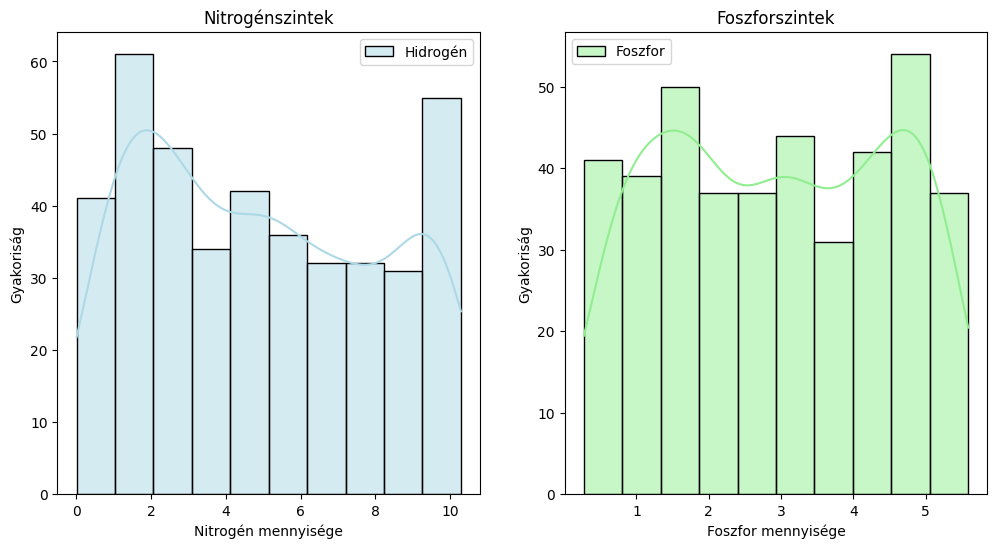

In [ ]:
plt.figure(figsize=(12,6))
plt.subplot(1,2,1)
sns.histplot(adatok['Nitrogen (mg/L)'],color='lightblue',edgecolor='black',kde=True,label="Hidrogén")
plt.title("Nitrogénszintek")
plt.xlabel("Nitrogén mennyisége")
plt.ylabel("Gyakoriság")
plt.legend()

plt.subplot(1,2,2)
sns.histplot(adatok['Phosphorus (mg/L)'],color='lightgreen',edgecolor='black',kde=True,label="Foszfor")
plt.title("Foszforszintek")
plt.xlabel("Foszfor mennyisége")
plt.ylabel("Gyakoriság")
plt.legend()
plt.show()

b) Ábrázoljuk a nitrogén szintek geográfiai eloszlását scatter-en, ahol a vízszintes tengelyen a
Longitude és a függőleges tengelyen a Latitude értékek szerepeljenek. A hue paramétert a
'Nitrogen (mg/L)' értékekre állítsuk be, és használjunk 'coolwarm' színpalettát. 2 pont

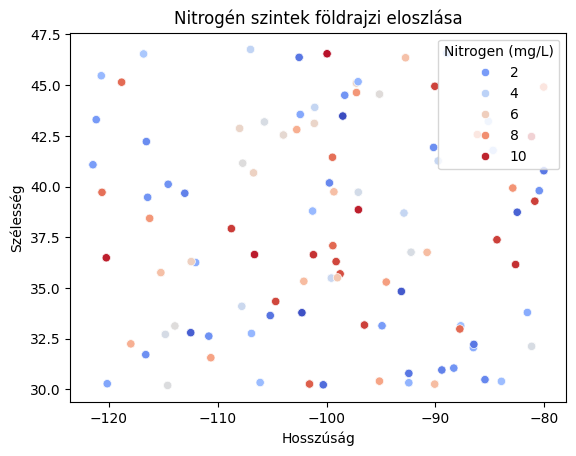

In [ ]:
sns.scatterplot(
    data=adatok,
    x='Geographical Location (Longitude)',
    y='Geographical Location (Latitude)',
    hue='Nitrogen (mg/L)',
    palette='coolwarm'
)
plt.title('Nitrogén szintek földrajzi eloszlása')
plt.xlabel('Hosszúság')
plt.ylabel('Szélesség')
plt.show()

5. feladat: Ábrázoljuk a foszfor szinteket valós térképen: Hozzuk létre a map objektumot
és jelenítsük meg az interaktív térképet az adott GPS koordináták alapján. 3 pont


In [ ]:
lat_mean = adatok['Geographical Location (Latitude)'].mean()
lon_mean = adatok['Geographical Location (Longitude)'].mean()

map = folium.Map(location=[lat_mean, lon_mean])

for _, sor in adatok.iterrows():
    folium.CircleMarker(
        location=[sor['Geographical Location (Latitude)'], sor['Geographical Location (Longitude)']],
        popup=f"Foszfor szint: {sor['Phosphorus (mg/L)']} mg/L",
        color='blue',
        fill=True,
    ).add_to(map)

map

NameError: name 'adatok' is not defined

6. feladat: A szennyvízrendszer állapota: Készítsünk gyakoriság diagramot a State of Sewage
System lehetséges állapotairól. Használjuk a Seaborn histplot metódusát és a kép méretét 6x6-
osra állítsuk be. A diagramot lássuk el jelmagyarázattal, diagramcímmel és tengelyfeliratokkal.
2,5 pont


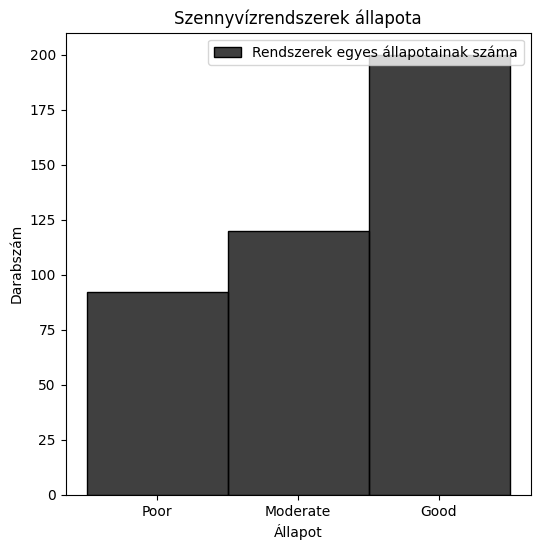

In [ ]:
plt.figure(figsize=(6,6))
sorrend = ['Poor', 'Moderate', 'Good']
sns.histplot(
    x=pd.Categorical(adatok['State of Sewage System'], categories=sorrend, ordered=True),
    color='black',
    edgecolor='black', label="Rendszerek egyes állapotainak száma"
)
plt.title("Szennyvízrendszerek állapota")
plt.xlabel("Állapot")
plt.ylabel("Darabszám")
plt.legend()
plt.show()

7. feladat: Korrelációs elemzés:

a) Vizsgáljuk meg az adatkészlet numerikus változói közötti korrelációt, hogy azonosítani
tudjuk az esetleges kapcsolatokat. Először hozzuk létre az N+P oszlopot, ahol a teljes mért
szennyezés értékét (a nitrogén és foszfor mennyiségek összegét) jelenítjük meg a mérési
helyeken, a mért időpontokban. 1 pont

In [ ]:
adatok['N+P'] = adatok['Nitrogen (mg/L)'] + adatok['Phosphorus (mg/L)']

print(adatok[['Nitrogen (mg/L)', 'Phosphorus (mg/L)', 'N+P']].head())

   Nitrogen (mg/L)  Phosphorus (mg/L)        N+P
0         5.447159           4.634808  10.081967
1         9.087964           3.129082  12.217047
2         0.485658           4.545678   5.031337
3         2.666448           4.090627   6.757075
4         8.425540           1.247981   9.673521


b) A szennyvízrendszer állapotát megadó State of Sewage System oszlop adatait konvertáljuk
számértértékké a LabelEncoder alkalmazásával. Ellenőrizzük az eredményt. 2 pont

In [ ]:
le = LabelEncoder()

adatok['State of Sewage System'] = le.fit_transform(adatok['State of Sewage System'])
print(adatok[['State of Sewage System']].head())

   State of Sewage System
0                       1
1                       0
2                       1
3                       2
4                       1


c) Válogassuk ki a csak numerikus adatokat tartalmazó oszlopokat egy új dataframe-be,
végezzük el a korreláció vizsgálatát a pearson módszer alkalmazásával.
A korreláció vizualizációhoz használjunk heatmap diagramot, a korrelációs együtthatók
megjelenítésével (3 tizedesjegyre kerekítve), coolwarm színtérképpel, 8x6-os képmérettel és
diagramcímmel. 4,5 pont

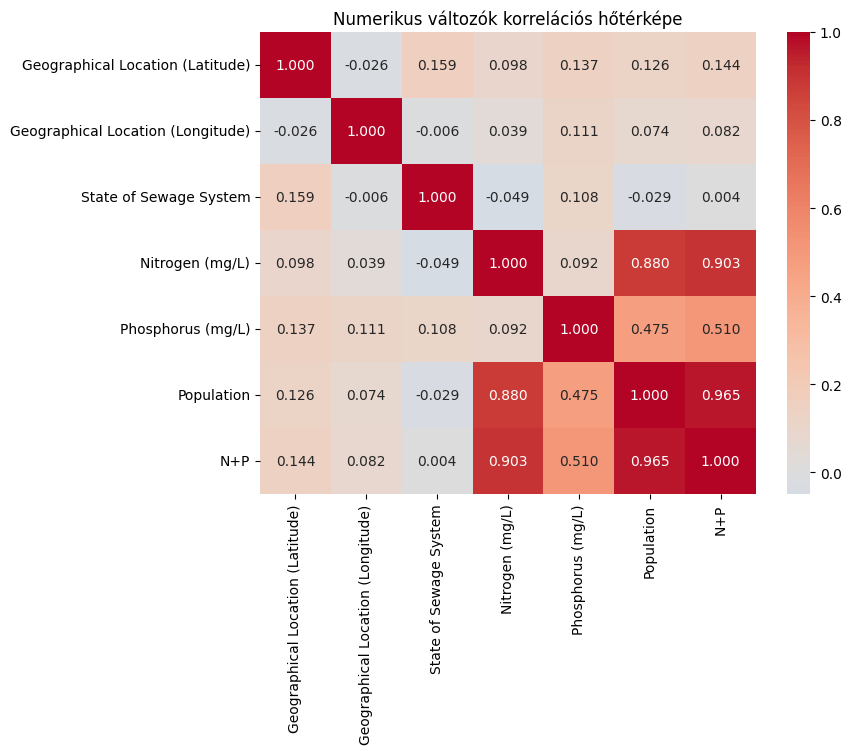

In [ ]:
numerikus_adatok = adatok.select_dtypes(include=['number'])
korrelacio = numerikus_adatok.corr(method='pearson')
plt.figure(figsize=(8, 6))
sns.heatmap(
    korrelacio,
    annot=True,
    fmt=".3f",
    cmap='coolwarm',
    center=0
)

plt.title('Numerikus változók korrelációs hőtérképe')
plt.show()

8. feladat: Rövidítsük a mezőneveket a következőképpen:

- Lati = Geographical Location (Latitude)
- Long = Geographical Location (Longitude)
- SDate = Sampling Date
- N = Nitrogen (mg/L)
- P = Phosphorus (mg/L)
- SWS = State of Sewage System

Ellenőrizzük az info() metódussal, hogy sikeres volt-e az átnevezés. 1,5 pont

In [ ]:
renames = {
    'Geographical Location (Latitude)': 'Lati',
    'Geographical Location (Longitude)': 'Long',
    'Sampling Date': 'SDate',
    'Nitrogen (mg/L)': 'N',
    'Phosphorus (mg/L)': 'P',
    'State of Sewage System': 'SWS'
}
adatok.rename(columns=renames, inplace=True)
adatok.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 412 entries, 0 to 411
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   Lati        412 non-null    float64       
 1   Long        412 non-null    float64       
 2   SWS         412 non-null    int64         
 3   SDate       412 non-null    datetime64[ns]
 4   N           412 non-null    float64       
 5   P           412 non-null    float64       
 6   Population  412 non-null    int64         
 7   N+P         412 non-null    float64       
dtypes: datetime64[ns](1), float64(5), int64(2)
memory usage: 25.9 KB


9. feladat: Készítsük el az adatok statisztikai jellemzését: Használjuk a describe() utasítást.
1 pont

In [ ]:
adatok.describe()

,Lati,Long,SWS,SDate,N,P,Population,N+P
count,412.000000,412.000000,412.000000,412,412.000000,412.000000,4.120000e+02,412.000000
mean,37.928978,-99.910523,0.737864,2019-02-16 10:08:09.320388352,4.956458,2.941068,9.041799e+05,7.897526
min,30.198108,-121.476341,0.000000,2014-01-02 00:00:00,0.004284,0.272931,2.053480e+05,0.379070
25%,33.138387,-107.997678,0.000000,2016-12-24 18:00:00,2.096088,1.593510,6.752212e+05,4.725642
50%,37.926803,-99.464055,1.000000,2018-12-08 12:00:00,4.821583,2.951642,8.774995e+05,7.935702
75%,42.542049,-90.071769,1.000000,2021-07-02 06:00:00,7.575510,4.327313,1.184369e+06,10.852442
max,46.759853,-80.039258,2.000000,2023-12-25 00:00:00,10.294660,5.586694,1.544160e+06,15.538928
std,5.088459,11.689830,0.800987,NaN,3.097449,1.544422,3.163950e+05,3.585622


10. feladat: Vizsgáljuk meg azokat a helyeket, ahol a N+P koncentráció magas. Ehhez
készítsünk egy Q (quality) oszlopot az apply függvény alkalmazásával, a következő értékekkel:
1, ha N+P 4-nél kisebb; 3, ha 10-nél nagyobb; a közbeeső tartományra az érték legyen 2.
Ellenőrizzük az eredményt. 2,5 pont

In [ ]:
def transcribe(num):
    if num < 4:
        return 1
    elif num > 10:
        return 3
    else:
        return 2
adatok['Q'] = adatok['N+P'].apply(transcribe)

adatok.head()

,Lati,Long,SWS,SDate,N,P,Population,N+P,Q
0,42.867278,-107.997678,1,2015-09-30,5.447159,4.634808,923253,10.081967,3
1,34.337029,-104.681197,0,2020-01-29,9.087964,3.129082,1196631,12.217047,3
2,34.831615,-93.134004,1,2017-09-09,0.485658,4.545678,781628,5.031337,2
3,45.463162,-120.709056,2,2019-11-12,2.666448,4.090627,855275,6.757075,2
4,41.444474,-99.464055,1,2016-08-19,8.425540,1.247981,1019428,9.673521,2


11. feladat: Csoportosítsuk a Q oszlop értékeit és írassuk ki a csoportok méretét. 1,5 pont

In [ ]:
sizes = adatok.groupby('Q').size()
print(sizes)

Q
1     77
2    193
3    142
dtype: int64


12. feladat: Jelenítsük meg a Q értékek geográfiai eloszlását Seaborn scatterplot-tal, coolwarm
színpalettával. A kép méretét 10x6-osra és a hue paramétert a Q értékekre állítsuk be. A
diagramot lássuk el jelmagyarázattal, diagramcímmel és tengelyfeliratokkal. 1 pont

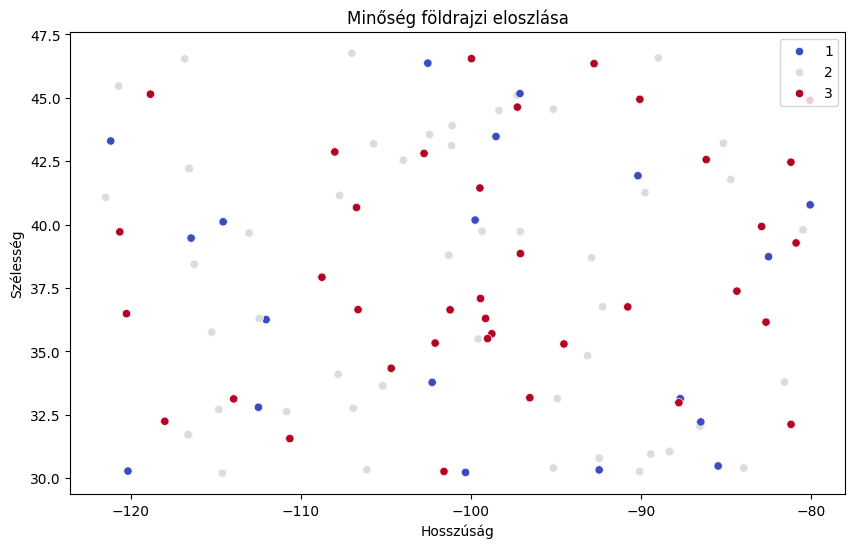

In [ ]:

plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=adatok,
    x='Long',
    y='Lati',
    hue='Q',
    palette='coolwarm',
)
plt.title('Minőség földrajzi eloszlása')
plt.xlabel('Hosszúság')
plt.ylabel('Szélesség')
plt.legend()
plt.show()


**Az adatok elemzése Machine Learning modellek alkalmazásával**

13. feladat: A következő részben készítsünk egy elemzést a DecisionTree modellel, a kapott modell értékelésével, és a döntési fa megjelenítésével. Importáljuk a szükséges modulokat és osztályokat a Scikit-learn könyvtárból.

Ebben az elemzésben nem használjuk a dátum adatokat, ezért a vizsgálathoz hozzunk létre egy új dataframe-et az SDate oszlop nélkül. Ellenőrizzük az új dataframe-et.

A modell alkalmazásához erre az új dataframe-re válasszuk szét az adathalmazt független (`x`)
és függő (`y`) változókra, az y értékeknek az SWS oszlopot választva. 4,5 pont

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import plot_tree

adatok = adatok.drop(columns=["SDate"])

x = adatok.drop(columns=["SWS"])
y = adatok["SWS"]

adatok.head()

,Lati,Long,SWS,N,P,Population,N+P,Q
0,42.867278,-107.997678,1,5.447159,4.634808,923253,10.081967,3
1,34.337029,-104.681197,0,9.087964,3.129082,1196631,12.217047,3
2,34.831615,-93.134004,1,0.485658,4.545678,781628,5.031337,2
3,45.463162,-120.709056,2,2.666448,4.090627,855275,6.757075,2
4,41.444474,-99.464055,1,8.425540,1.247981,1019428,9.673521,2


14. feladat: **Adatok felosztása, modellépítés és betanítás. Vizualizáció**

Osszuk fel az adatokat 4:1 arányban véletlenszerűen train és test adatokra, és tanítsuk be a
modellünket. Vizualizáljuk a döntési fát a Matplotlib segítségével, az ábra méretét célszerű
12x8-ra beállítani. 4 pont

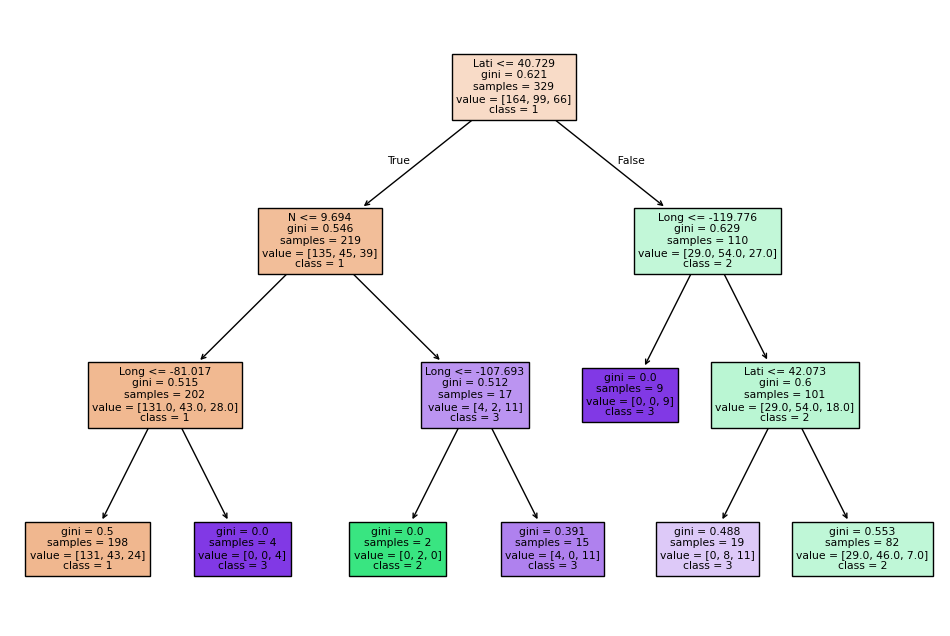

In [ ]:
x_tanuló, x_teszt, y_tanuló, y_teszt = train_test_split(x, y, test_size=0.2, random_state=42)

dontesi_fa = DecisionTreeClassifier(max_depth=3, random_state=42)
dontesi_fa.fit(x_tanuló, y_tanuló)

plt.figure(figsize=(12, 8))
plot_tree(dontesi_fa, feature_names=x.columns, class_names=["1","2","3"], filled=True)
plt.show()

15.feladat: A modell értékelése

Készítsünk predikciót a teszt halmazon. Számítsuk ki a pontosságot. Generáljunk osztályozási
riportot és konfúziós mátrixot és ezeket jelenítsük meg. 4 pont

A modell pontossága: 0.5301
Osztályozási riport:
              precision    recall  f1-score   support

           0       0.48      0.56      0.51        36
           1       0.42      0.52      0.47        21
           2       0.87      0.50      0.63        26

    accuracy                           0.53        83
   macro avg       0.59      0.53      0.54        83
weighted avg       0.59      0.53      0.54        83



<Figure size 800x600 with 0 Axes>

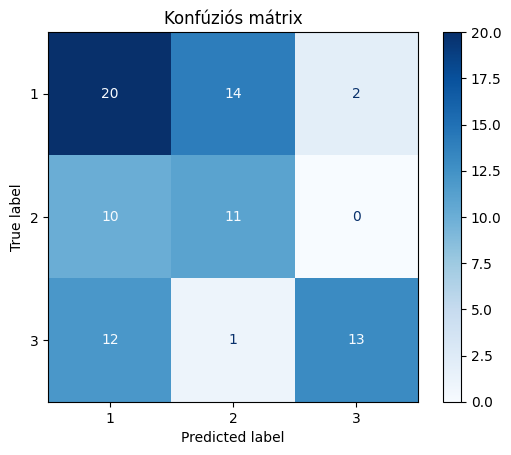

In [ ]:
y_tipp = dontesi_fa.predict(x_teszt)

pontossag = accuracy_score(y_teszt, y_tipp)
print(f"A modell pontossága: {pontossag:.4f}")

print("Osztályozási riport:")
print(classification_report(y_teszt, y_tipp))

plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_teszt, y_tipp)
display = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["1", "2", "3"])
display.plot(cmap='Blues')
plt.title("Konfúziós mátrix")
plt.show()

16. feladat: A népesség és a szennyezettség mértékének kapcsolatának vizsgálata Lineáris
Regresszióval

A következő részben készítsünk egy elemzést a LinearRegression modellel, a kapott modell
értékelésével, és a scatter diagram megjelenítésével. Először importáljuk a szükséges
modulokat és osztályokat a Scikit-learn könyvtárból. Független változónak a Population
oszlopot, és függő változónak az N+P oszlopot válasszuk.

Osszuk fel az adatokat 4:1 arányban véletlenszerűen train és test adatokra, és tanítsuk be a
modellünket. Vizualizáljuk a teszt adatokat és a lineáris regressziót is jelenítésük meg a
Matplotlib scatter alkalmazásával. 8,5 pont

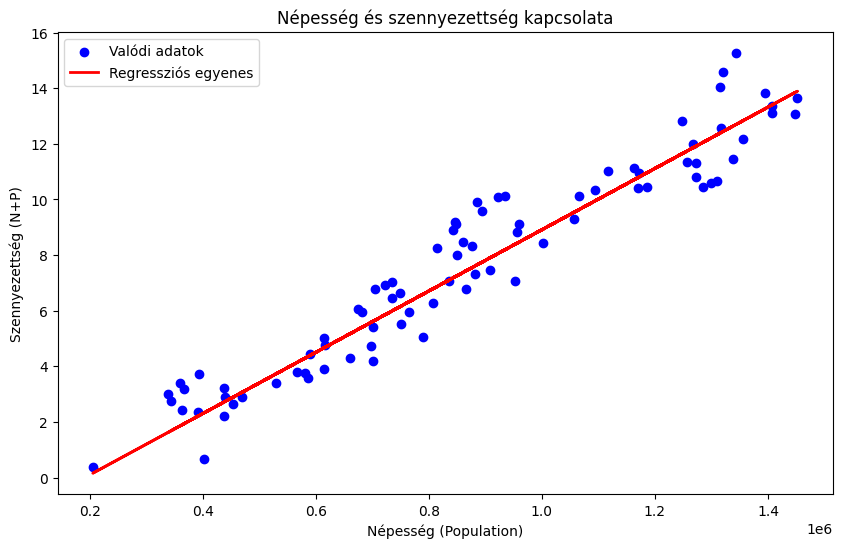

In [ ]:
from sklearn.linear_model import LinearRegression

x = adatok[['Population']]
y = adatok['N+P']

x_tanulo, x_teszt, y_tanulo, y_teszt = train_test_split(x, y, test_size=0.2, random_state=42)

regresszio = LinearRegression()
regresszio.fit(x_tanulo, y_tanulo)

plt.figure(figsize=(10, 6))
plt.scatter(x_teszt, y_teszt, color='blue', label='Valódi adatok')

y_pred = regresszio.predict(x_teszt)
plt.plot(x_teszt, y_pred, color='red', linewidth=2, label='Regressziós egyenes')

plt.title('Népesség és szennyezettség kapcsolata')
plt.xlabel('Népesség (Population)')
plt.ylabel('Szennyezettség (N+P)')
plt.legend()
plt.show()

17. feladat: A modell értékelése

Készítsünk predikciót a teszt halmazon, és jelenítsük meg az első öt predikció, és az első öt
valós y teszt értékeket. Írassuk ki a betanított modellünk pontosságát is. 4 pont

In [ ]:
y_pred = regresszio.predict(x_teszt)

print("Az első 5 jósolt érték:")
print(y_pred[:5])
print()
print("Az első 5 valós érték:")
print(y_teszt.values[:5])
print()
pontossag = regresszio.score(x_teszt, y_teszt)
print(f"A modell pontossága: {pontossag:.4f}")

Az első 5 jósolt érték:
[5.41130086 7.64173826 7.10500045 4.66348416 5.17507805]

Az első 5 valós érték:
[5.94757339 9.90639491 7.06354842 5.00048622 4.28705414]

A modell pontossága: 0.9196
